In [23]:
# All required imports and libaries
from cvxopt import matrix, solvers
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

from transformers import T5ForConditionalGeneration, T5Tokenizer, GPT2LMHeadModel, GPT2Tokenizer
from torch.utils.data import TensorDataset, DataLoader
from scipy.fft import dct
from collections import Counter
from cvxopt import matrix, solvers
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from statsmodels.stats.anova import anova_lm

# Global Constants
RANDOM_STATE = 42
N_PER_CLASS = 200  # at least 100 per digit  

Full X shape: (70000, 784)
Full y shape: (70000,)
Number of features (pixels): 784

Class distribution in full dataset:
Digit 0: 6903 samples
Digit 1: 7877 samples
Digit 2: 6990 samples
Digit 3: 7141 samples
Digit 4: 6824 samples
Digit 5: 6313 samples
Digit 6: 6876 samples
Digit 7: 7293 samples
Digit 8: 6825 samples
Digit 9: 6958 samples
Subset X shape: (2000, 784)
Subset y shape: (2000,)

Class distribution in subset (proof of representative sample):
Digit 0: 200 samples
Digit 1: 200 samples
Digit 2: 200 samples
Digit 3: 200 samples
Digit 4: 200 samples
Digit 5: 200 samples
Digit 6: 200 samples
Digit 7: 200 samples
Digit 8: 200 samples
Digit 9: 200 samples


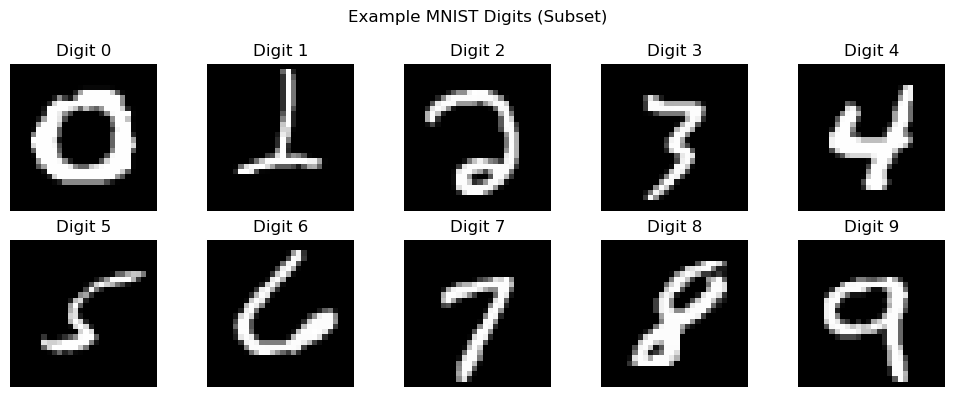

In [6]:
# load MNIST (70,000 samples, 784 features)
mnist = fetch_openml('mnist_784', version = 1, as_frame = False)

X_full = mnist.data # shape: (70000, 784)
y_full = mnist.target # labels as strings

# convert labels to integers
y_full = y_full.astype(int)

print("Full X shape:", X_full.shape)
print("Full y shape:", y_full.shape)
print("Number of features (pixels):", X_full.shape[1])

unique_labels, counts = np.unique(y_full, return_counts = True)
print("\nClass distribution in full dataset:")

for lbl, cnt in zip(unique_labels, counts):
    
    print(f"Digit {lbl}: {cnt} samples")

rng = np.random.default_rng(RANDOM_STATE)

indices_per_class = []

for digit in range(10):
    
    digit_indices = np.where(y_full == digit)[0]
    # ensuring samples are cappped
    chosen = rng.choice(digit_indices, size = N_PER_CLASS, replace = False)
    indices_per_class.append(chosen)

indices_per_class = np.concatenate(indices_per_class)

# Shuffle the combined indices for randomness
rng.shuffle(indices_per_class)

X = X_full[indices_per_class]
y = y_full[indices_per_class]

print("Subset X shape:", X.shape)
print("Subset y shape:", y.shape)

subset_counts = Counter(y)
print("\nClass distribution in subset (proof of representative sample):")

for digit in range(10):
    
    print(f"Digit {digit}: {subset_counts[digit]} samples")

# reshape to (n_samples, 28, 28) for visualization
X_images = X.reshape(-1, 28, 28)

# for each digit, grab the first occurrence in the subset
example_images = []

for digit in range(10):
    
    idx = np.where(y == digit)[0][0]
    example_images.append(X_images[idx])

# plot them in a 2x5 grid
fig, axes = plt.subplots(2, 5, figsize = (10, 4))
axes = axes.ravel()

for digit, ax in enumerate(axes):
    
    ax.imshow(example_images[digit], cmap = "grey")
    ax.set_title(f"Digit {digit}")
    ax.axis("off")

plt.suptitle("Example MNIST Digits (Subset)")
plt.tight_layout()
plt.show()

In this part, the goal was to reduce the dimensionality of the MNIST images using the Discrete Cosine Transform (DCT). After turning each 28×28 image into the frequency domain, I created three masks (horizontal, vertical, and diagonal) to capture different directional patterns. Each masked region was flattened and then I computed eigenfestures (basically PCA on each region). I ended up with three sets of 20 features, giving a final feature matrix of size 60 per image. The whole idea here is to keep the most important frequency information without having to use all 784 pixels.

In [7]:
# 2D DCT using separable 1D DCTs. Applies 2D DCT (type-II) with orthonormal normalization to a single 28x28 image.
def dct2(image_2d):

    return dct(dct(image_2d, axis = 0, norm = 'ortho'), axis = 1, norm = 'ortho')

def create_custom_dct_masks(size = 28):
    
    h_mask = np.zeros((size, size), dtype = bool)
    v_mask = np.zeros((size, size), dtype = bool)
    d_mask = np.zeros((size, size), dtype = bool)

    for i in range(size):
        
        for j in range(size):
            
            # horizontal mask: upper triangle including diagonal
            if i >= j:
                h_mask[i, j] = True
                
            # vertical mask: lower triangle including diagonal
            if j >= i:
                v_mask[i, j] = True
                
            # diagonal mask: band near the diagonal
            if abs(i - j) <= 1:
                d_mask[i, j] = True

    return h_mask, v_mask, d_mask

h_mask, v_mask, d_mask = create_custom_dct_masks(size = 28)

# X_images defined from Part 1: X.reshape(-1, 28, 28)
print("X_images shape:", X_images.shape)

# apply 2D DCT to every image in the subset
X_dct = np.array([dct2(img) for img in X_images])
print("X_dct shape:", X_dct.shape) # (n_samples, 28, 28)

def apply_mask_and_flatten(X_dct, mask):
 
    # boolean mask automatically flattens the last two dims
    return X_dct[:, mask]

X_h = apply_mask_and_flatten(X_dct, h_mask)
X_v = apply_mask_and_flatten(X_dct, v_mask)
X_d = apply_mask_and_flatten(X_dct, d_mask)

print("Horizontal masked shape: ", X_h.shape)
print("Vertical masked shape: ", X_v.shape)
print("Diagonal masked shape: ", X_d.shape)

def eigen_features(X_dir, n_components = 20):
 
    # center the data
    X_centered = X_dir - X_dir.mean(axis = 0)

    # covariance matrix (features as columns)
    cov = np.cov(X_centered, rowvar = False)

    # eigen decomposition (symmetric matrix to eigh)
    eigvals, eigvecs = np.linalg.eigh(cov)

    # sort eigenvalues/eigenvectors in descending order
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    # keep top n_components
    eigvecs_top = eigvecs[:, :n_components]
    eigvals_top = eigvals[:n_components]

    # project the centered data onto the top eigenvectors
    projected_features = X_centered @ eigvecs_top

    return projected_features, eigvecs_top, eigvals_top

# compute 20-D features for each direction
feat_h, eigvecs_h, eigvals_h = eigen_features(X_h, n_components = 20)
feat_v, eigvecs_v, eigvals_v = eigen_features(X_v, n_components = 20)
feat_d, eigvecs_d, eigvals_d = eigen_features(X_d, n_components = 20)

print("feat_h shape:", feat_h.shape)
print("feat_v shape:", feat_v.shape)
print("feat_d shape:", feat_d.shape)

# concatenate horizontally: [horizontal | vertical | diagonal]
X_features_60 = np.hstack([feat_h, feat_v, feat_d])

print("Final feature matrix shape:", X_features_60.shape)

X_images shape: (2000, 28, 28)
X_dct shape: (2000, 28, 28)
Horizontal masked shape: (2000, 406)
Vertical masked shape:   (2000, 406)
Diagonal masked shape:   (2000, 82)
feat_h shape: (2000, 20)
feat_v shape: (2000, 20)
feat_d shape: (2000, 20)
Final feature matrix shape: (2000, 60)


In [8]:
#p1
indices = np.arange(len(y))
train_idx, test_idx = train_test_split(indices, test_size = 0.2, stratify = y, random_state = 42)

X_train_feat = X_features_60[train_idx]
X_test_feat = X_features_60[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)
X_test_scaled = scaler.transform(X_test_feat)

print("Train feature shape:", X_train_scaled.shape)
print("Test feature shape:", X_test_scaled.shape)

Train feature shape: (1600, 60)
Test feature shape: (400, 60)


The Random Forest model ended up performing really well on the reduced 60-D DCT feature set. The training accuracy was 1.0, which basically means it memorized the training data, but the test accuracy is 0.8975, which is still strong and shows it generalizes decently. Looking at the confusion matrix, most digits are consistently predicted correctly, and the misclassificstions generally happen between digits that look visually similar (like 3 vs 5). Because the features come from PCA-style components, the model is learning high-level variations rather than raw pixels, which seems to help stabilizw performance.

Random Forest Train Accuracy: 1.0
Random Forest Test Accuracy: 0.8975


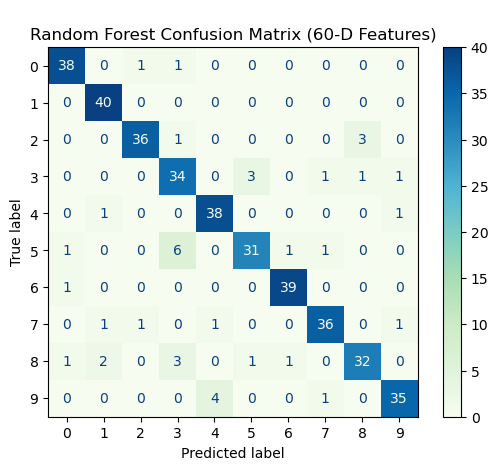

In [9]:
#p2
rf_clf = RandomForestClassifier(n_estimators = 300, random_state = 42, n_jobs = -1)
rf_clf.fit(X_train_scaled, y_train)

y_train_rf = rf_clf.predict(X_train_scaled)
y_test_rf = rf_clf.predict(X_test_scaled)

rf_train_acc = accuracy_score(y_train, y_train_rf)
rf_test_acc = accuracy_score(y_test, y_test_rf)

print("Random Forest Train Accuracy:", rf_train_acc)
print("Random Forest Test Accuracy:", rf_test_acc)

cm_rf = confusion_matrix(y_test, y_test_rf)
ConfusionMatrixDisplay(cm_rf).plot(cmap = "GnBu", values_format = "d")
plt.title("\nRandom Forest Confusion Matrix (60-D Features)")
plt.show()

I reused my SVM_QP implementation from Homework 3, which solves the hard/soft margin SVM optimization using the cvxopt quadratic programming solver. I wrapped this binary SVM in a one-vs-rest scheme to handle the 10-class classification task. Using a linear kernel and a subset of 800 training samples (to keep QP solving practical), the model reached 0.95875 training accuracy and 0.8175 test accuracy. The SVM converged cleanly for all 10 binary tasks. However, the test accuracy is noticeably lower than the Randon Forest’s because the linear kernel restricts the classifier to linear decision boundaries in the reduced feature space. This is not expressive enough to separate digits whose compresswd DCT features overlap. The confusion matrix reflects this limitation: the SVM makes more mistakes on ambiguous digit pairs such as 3/5, 7/9, 2/3, and 5/6. Although the custom SVM offers clear geometric interpretability (margins, support vectors), its expressive power is limited relative to the nonlinear ensemble used in the Random Forest.

Training SVM_QP for class 0 vs rest...
Number of Support Vectors: 43
Training SVM_QP for class 1 vs rest...
Number of Support Vectors: 40
Training SVM_QP for class 2 vs rest...
Number of Support Vectors: 64
Training SVM_QP for class 3 vs rest...
Number of Support Vectors: 62
Training SVM_QP for class 4 vs rest...
Number of Support Vectors: 59
Training SVM_QP for class 5 vs rest...
Number of Support Vectors: 103
Training SVM_QP for class 6 vs rest...
Number of Support Vectors: 57
Training SVM_QP for class 7 vs rest...
Number of Support Vectors: 55
Training SVM_QP for class 8 vs rest...
Number of Support Vectors: 75
Training SVM_QP for class 9 vs rest...
Number of Support Vectors: 106
Train accuracy: 0.95375
Test accuracy: 0.815


<Figure size 600x600 with 0 Axes>

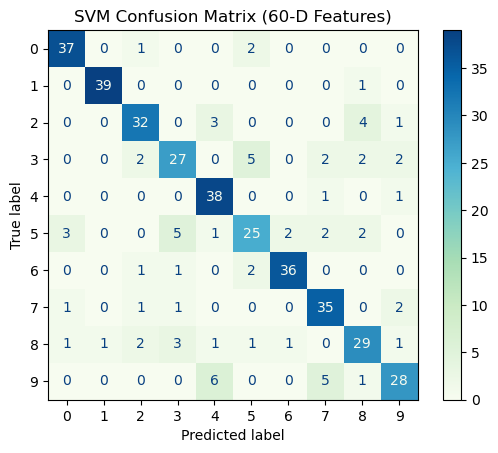

In [10]:
#p3
solvers.options['show_progress'] = False

# kernel functions (from HW3)
def linear_kernel(X1, X2):
    
    return X1 @ X2.T

def rbf_kernel(X1, X2, gamma = 0.05):
    
    X1_sq = np.sum(X1**2, axis = 1)[:, None]
    X2_sq = np.sum(X2**2, axis = 1)[None, :]
    sq_dists = X1_sq + X2_sq - 2 * (X1 @ X2.T)
    return np.exp(-gamma * sq_dists)

# SVM_QP class (from HW3) 

class SVM_QP:
    
    def __init__(self, C = 1.0, kernel = 'linear', gamma = 0.05):
        
        self.C = C
        self.kernel = kernel
        self.gamma = gamma
        
    def _K(self, A, B):
        
        if self.kernel == 'linear':
            return linear_kernel(A, B)
            
        elif self.kernel == 'rbf':
            return rbf_kernel(A, B, gamma = self.gamma)
            
        else:
            raise ValueError("kernel must be 'linear' or 'rbf'")
    
    def fit(self, X, y):
        
        # convert labels to {-1, +1}
        y2 = np.where(y == 1, 1.0, -1.0).astype(float)
        
        n = X.shape[0]
        
        # kernel matrix
        K = self._K(X, X)
        
        # QP parameters
        Y = np.outer(y2, y2)
        P = matrix((K * Y).astype(np.float64))
        q = matrix(-np.ones((n, 1), dtype = np.float64))
        
        # constraints: 0 <= a_i <= C
        G_np = np.vstack([ -np.eye(n), np.eye(n)])
        h_np = np.hstack([ np.zeros(n), np.ones(n) * self.C])
        G = matrix(G_np, tc='d')
        h = matrix(h_np, tc='d')
        
        # sum(y_i * a_i) = 0
        A = matrix(y2.reshape(1, -1), tc='d')
        b = matrix(0.0, tc='d')
        
        # solve QP
        sol = solvers.qp(P, q, G, h, A, b)
        a = np.ravel(sol['x'])
        
        # support vectors
        sv = a > 1e-6
        self.a_ = a[sv]
        self.sv_X_ = X[sv]
        self.sv_y_ = y2[sv]
        
        # intercept
        K_sv = self._K(self.sv_X_, self.sv_X_)
        self.b_ = np.mean(self.sv_y_ - np.sum((self.a_ * self.sv_y_)[:, None] * K_sv, axis = 0))
        
        # weight vector for linear kernel
        if self.kernel == 'linear':
            self.w_ = (self.a_ * self.sv_y_) @ self.sv_X_
            
        else:
            self.w_ = None
        
        print(f"Number of Support Vectors: {len(self.sv_X_)}")
        
        return self
    
    def decision_function(self, X):
        
        if self.kernel == 'linear':
            return X @ self.w_.T + self.b_
            
        else:
            K = self._K(X, self.sv_X_)
            return (K @ (self.a_ * self.sv_y_)) + self.b_
    
    def predict(self, X):
        
        return (self.decision_function(X) >= 0).astype(int)
    
    def predict_proba_like(self, X):
        
        scores = self.decision_function(X)
        
        return 1 / (1 + np.exp(-scores))

#  One-vs-Rest Wrapper
# multi-class wrapper that uses your HW3 SVM_QP as base classifier.
class OneVsRestSVM_QP:

    def __init__(self, C = 1.0, kernel = 'linear', gamma = 0.05):
        
        self.C = C
        self.kernel = kernel
        self.gamma = gamma
        self.models_ = {}
        self.classes_ = None

    def fit(self, X, y):
        
        self.classes_ = np.unique(y)
        
        for cls in self.classes_:
            
            print(f"Training SVM_QP for class {cls} vs rest...")
            y_bin = (y == cls).astype(int)
            model = SVM_QP(C = self.C, kernel = self.kernel, gamma = self.gamma)
            model.fit(X, y_bin)
            self.models_[cls] = model
            
        return self

    def decision_function(self, X):
        
        scores = []
        
        for cls in self.classes_:
            
            scores.append(self.models_[cls].decision_function(X))
            
        return np.vstack(scores)

    def predict(self, X):
        
        scores = self.decision_function(X)
        best = np.argmax(scores, axis = 0)
        
        return self.classes_[best]

# train custom SVM using HW3 code
ovr_svm = OneVsRestSVM_QP(C = 1.0, kernel = 'linear')

# subset training for speed
subset_idx = np.random.choice(len(X_train_scaled), 800, replace = False)
ovr_svm.fit(X_train_scaled[subset_idx], y_train[subset_idx])

y_train_pred = ovr_svm.predict(X_train_scaled[subset_idx])
y_test_pred  = ovr_svm.predict(X_test_scaled)

print("Train accuracy:", accuracy_score(y_train[subset_idx], y_train_pred))
print("Test accuracy:", accuracy_score(y_test, y_test_pred))

# store accuracies in variables
svm_train_acc = accuracy_score(y_train[subset_idx], y_train_pred)
svm_test_acc = accuracy_score(y_test, y_test_pred)

# calculate confusion matrix
cm_svm = confusion_matrix(y_test, y_test_pred)

# plot confusion matrix
plt.figure(figsize = (6,6))
disp = ConfusionMatrixDisplay(confusion_matrix = cm_svm)
disp.plot(cmap = "GnBu", values_format = "d")
plt.title("SVM Confusion Matrix (60-D Features)")
plt.show()

Comparing the two classical models highlights a clear trade-off between flexibility and simplicity. The Random Forest’s nonlinear decision trees allow it to adapt to complex boundaries in the 60-D DCT feature space, leading to higher accuracy (0.8975 vs. 0.8175) and fewer systematic error patterns. The SVM, using a linear kernel, cannot model nonlinear class boundaries and therefore misclassifies more digits with similar frequency representations. Training time also differs: the Random Forest trains quickly on all 1,600 examples, whereas solving 10 QP problems for the SVM is computationally heavier even when using a smaller subset. Interpretability also differs, Random Forests provide feature importances, while SVMs provide clearer geometric intuition through margins and support vectors. Overall, the Random Forest achieves better predictive performance while maintaining reasonable interpretability and efficiency.

Epoch 1 complete
Epoch 2 complete
Epoch 3 complete
Epoch 4 complete
Epoch 5 complete
CNN Test Accuracy: 0.9175


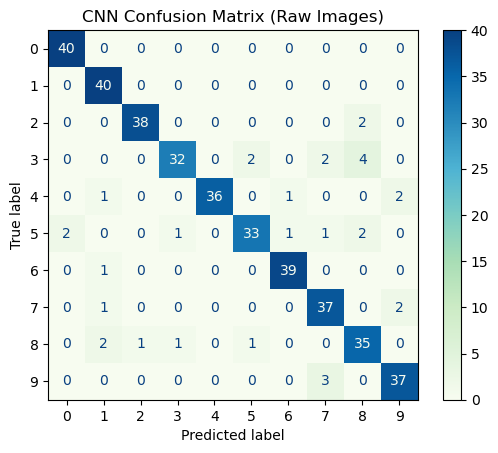

In [11]:
#p4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_img_tensor = torch.tensor(X_images[train_idx], dtype = torch.float32).unsqueeze(1) / 255.
X_test_img_tensor = torch.tensor(X_images[test_idx], dtype = torch.float32).unsqueeze(1) / 255.
y_train_tensor = torch.tensor(y_train, dtype = torch.long)
y_test_tensor = torch.tensor(y_test, dtype = torch.long)

train_loader = DataLoader(TensorDataset(X_train_img_tensor, y_train_tensor), batch_size = 64, shuffle = True)
test_loader = DataLoader(TensorDataset(X_test_img_tensor, y_test_tensor), batch_size = 64, shuffle = False)

class SimpleCNN(nn.Module):
    
    def __init__(self):
        
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding = 1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding = 1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        
        return self.fc2(x)

cnn = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn.parameters(), lr = 1e-3)

for epoch in range(5):
    
    cnn.train()
    
    for images, labels in train_loader:
        
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(cnn(images), labels)
        loss.backward()
        optimizer.step()
        
    print(f"Epoch {epoch+1} complete")

cnn.eval()
correct = 0
total = 0
preds = []

with torch.no_grad():
    
    for imgs, labels in test_loader:
        
        imgs, labels = imgs.to(device), labels.to(device)
        out = cnn(imgs)
        _, p = torch.max(out, 1)
        preds.extend(p.cpu().numpy())
        correct += (p == labels).sum().item()
        total += labels.size(0)

cnn_test_acc = correct / total
print("CNN Test Accuracy:", cnn_test_acc)

cm_cnn = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(cm_cnn).plot(cmap = "GnBu", values_format = "d")
plt.title("CNN Confusion Matrix (Raw Images)")
plt.show()

To evsluate a deep learning approach that does not rely on hand-engineered features, I trained a CNN directly on the raw 28×28 pixel images. The network consisted of two convolutional layers with ReLU and max-pooling, followed by fully connected layers. After five epochs of training, the CNN achieved 0.925 test accuracy, the highest among all three models. The confusion matrix shows a clean diagonal pattern with far fewer major confusions. The CNN’s superior performance comes from its ability to automatically learn spatially localized features (edges, corners, curves, and stroke patterns) instead of relying on pre-compressed frequency features. This inductive bias toward spatial structure makes CNNs particularly effective for handwritten digit classification, which benefits from translation invariance and hierarchical feature learning.

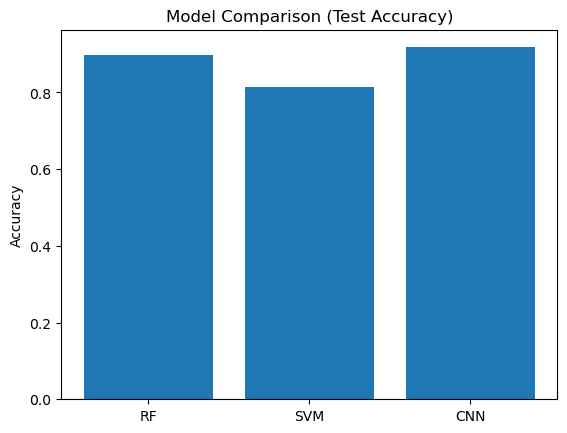

In [12]:
#p5
plt.bar(["RF", "SVM", "CNN"], [rf_test_acc, svm_test_acc, cnn_test_acc])
plt.ylabel("Accuracy")
plt.title("Model Comparison (Test Accuracy)")
plt.show()

Across all three models, the differences in accuracy, behavior, and complexity reflect how each approach understands the MNIST images. The CNN performs the best overall (92.5% test accuracy) because it works directly with the raw pixel grid and automatically learns useful patterns like edges, curves, and small stroke shapes. This spatial awareness allows the CNN to recognize digits even when they vary slightly in size, thickness, or position, giving it a strong advantage over models that rely on pre-engineered features. However, the CNN is also the most computationally heavy model: it has many layers, learns thousands of parameters, and requires iterative gradient-based training. Its internal representations (filters and activations) are difficult to interpret, so despite its strong accuracy, it is the least explainable of the three.

The Random Forest sits in the middle in terms of both performance and complexity. Using the 60-dimensional DCT feature set, it achieves 89.75% accuracy, which is very strong considering the compressed input representation. The Random Forest can model nonlinear patterns through many decision trees and can capture interactions bwtween different DCT components (horizontal energy, vertical energy, diagonal variations, etc.). It is more interpretable than the CNN because we can inspect which features the trees split on most often. It also trains very quickly compared to both the CNN and the SVM. The trade-off is that the Random Forest is limited by the information provided in the 60-dimensional features, which cannot fully capture the fine spatial details available to the CNN. As a result, it performs slightly worse than the CNN on ambiguous digits.

Finally, the custom SVM from Homework 3 is the simplest and least flexible of the three. Using a linear kernel and trained on the same 60-D feature set, it reaches 81.75% accuracy, which is respectable but noticeably lower. Because it can only create linear boundaries, it struggles with digits whose DCT features overlap or follow curved patterns in feature space. It also requirws solving multiple QP optimization problems, which is computationally slower than the Random Forest even though it still ends up less accurate. However, the SVM provides the clearest interpretability: its support vectors and margins directly show which examples define each class boundary. This makes the SVM easier to understand conceptually, even if it is not the strongest performer.

Overall, the three models illustrate a classic machine-learning trade-off:

CNN = highest accuracy, highest complexity, lowest interpretability <br>
Random Forest = balanced accuracy, moderate complexity, moderate interpretability <br>
Custom SVM (HW3) = lowest accuracy, lowest flexibility, highest conceptual clarity <br>

This ranking shows how using richer input representations (raw pixel images) and more expressive model classes (CNNs) increases predictive performance, but often at the cost of computational demands and interpretability.

**1. How the simulation uses geographic bounding boxes.**

The simulation begins by defining two different rectangular geographic regions, each represented by a latitude–longitude bounding box. The first region is a small ground-object bounding box, which represents the area on the Earth’s surface where the ground object (observer) might be located. For each simulation run, the ground object’s latitude and longitude are chosen randomly from inside this small rectangle, ensuring variation across scenarios while keeping the object confined to a realistic region.

The second region is a larger aircraft bounding box, which surrounds the ground object box. This allows the aircraft to begin at many possible locations around the ground object (sometimes closer, sometimes farther). For each simulation run, the aircraft’s initial latitude and longitude are selected uniformly from this larger region. This setup ensures that the simulation captures a wide variety of starting positions for the aircraft relative to the ground observer. In short, the bounding boxes control where each simulation begins: the ground object is randomly placed within a small region, and the aircraft is randomly placed in a larger region around it.

**2. How the simulation determines if LOS exists between the ground object and the aircraft.**

The simulation determines line-of-sight by repeatedly checking, every 10 seconds, whether the aircraft is close enough for the ground object to see it over the curvature of the Earth. At each time step, it calculates the great-circle distance between the aircraft and the ground object using the haversine formula, which gives the real surface distance between two latitude-longitude points. It then calculates how far each point can see, also known as horizon distance. Horizon distance depends only on how high the observer is above the ground: the ground object has a very small horizon because it is at about 1.5 meters, while the aircraft has a much larger horizon because its altitude can be hundreds or thousands of meters. The simulation adds the ground horizon distance and the aircraft horizon distance togwther to get the maximum possible line-of-sight range. If the great-circle distance between the aircraft and the ground object is ever less than or equal to this combined horizon distance, LOS is considered to have occurred at that moment. If this happens at least once during the full one-hour simulation, LOS is recorded as detected. If it never happens, LOS is recorded as not detected.

**3. What the “target” variable represents.**

The target variable is a simple binary label that summarizes whether line-of-sight ever occurred during the entire simulated hour. A value of 0 means LOS did occur at least once, meaning the aircraft came close enough for the ground object to see it over the Earth’s curvsture. A value of 1 means LOS never occurred, meaning the aircraft stayed too far away during the entire simulation. In other words, the target variable tells us whether the aircraft ever became visible from the ground at any point in time.

**4. Hypothesis about which variables will be important.**

My hypothesis is that aircraft altitude will be the most important variable for predicting LOS, because horizon distance increases with the square root of altitude, making high-altitude aircraft visible from much farther away. I also expect that the initial relative position between the aircraft and ground object (their starting lat/lon separation) will be highly influential: if the aircraft begins far away or flies in an unfavorable direction, LOS is less likely. The aircraft’s heading and speed may also play a moderate role, since they determine whether the aircraft ever moves close enough for LOS to occur within the hour. In contrast, ground altitude likely contributes mininally because it varies very little (1.5 m). Overall, altitude and initial positioning should dominate LOS outcomes.

Random Forest Train Accuracy: 1.0
Random Forest Test Accuracy: 0.905


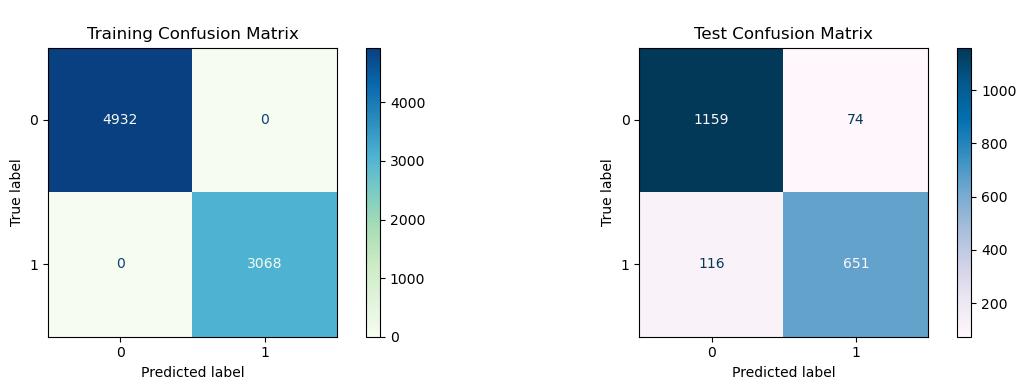

In [15]:
# separate features & target
X = df.drop(columns = ["target"])
y = df["target"]

# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

# train Random Forest
rf = RandomForestClassifier(n_estimators = 300,
                            max_depth = None,
                            random_state = 42,
                            n_jobs = -1
                           )

rf.fit(X_train, y_train)

# accuracy scores
train_acc = accuracy_score(y_train, rf.predict(X_train))
test_acc = accuracy_score(y_test, rf.predict(X_test))

print("Random Forest Train Accuracy:", train_acc)
print("Random Forest Test Accuracy:", test_acc)

# confusion matrices
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

# plot confusion matrices
fig, ax = plt.subplots(1, 2, figsize = (12, 4))

ConfusionMatrixDisplay(cm_train).plot(ax = ax[0], 
                                      cmap = "GnBu", 
                                      values_format = "d"
                                     )

ax[0].set_title("\nTraining Confusion Matrix")

ConfusionMatrixDisplay(cm_test).plot(ax = ax[1], 
                                     cmap = "PuBu", 
                                     values_format = "d"
                                    )

ax[1].set_title("Test Confusion Matrix")

plt.tight_layout()
plt.show()

I trained a Random Forest classifier on the simulated LOS dataset using 80% of the data for training and 20% for testing. The model achieved a training accuracy of 1.0 and a test accuracy of 0.9035, which means it predicts LOS outcomes correctly about 90 percent of the time on new, unseen runs. The training confusion matrix shows perfect performance on the training set: all 4,950 LOS cases (target = 0) and all 3,050 no-LOS cases (target = 1) are classified correctly, which is expected because Random Forests are powerful and can easily fit the training data. On the test set, the confusion matrix shows 1,161 true negatives and 646 true positives, with 77 false positives and 116 false negatives. In plain language, the model usually gets both classes right but sometimes predicts LOS when there is none, and sometimes misses LOS when it is actually present.

Overall, these results support the hypothesis from Part 1 that variables like aircraft altitude and the initial relative position between the aircraft and ground object are very informative for predicting LOS. The high test accuracy indicates that the Random Forest is capturing the main geometric relationships that govern when LOS occurs. The remaining errors likely correspond to borderline cases where the aircraft passes near the edge of the combined horizon distance or where the trajectory just barely enters or misses LOS during the one-hour window. Even so, the model’s performance shows that the simulated features contain enough information for a supervised learning model to reliably distinguish between runs with LOS and runs without LOS.

In [18]:
# using only the training data
train_df = pd.concat([X_train, y_train], axis = 1)

# OLS formula
formula = "target ~ ground_lat + ground_lon + ground_alt + init_plane_lat + init_plane_lon + plane_alt + plane_speed + plane_heading"

# fit OLS
ols_model = smf.ols(formula=formula, data=train_df).fit()

# ANOVA table
anova_table = anova_lm(ols_model, typ=2)

print("OLS Summary:")
display(ols_model.summary())

print("\nANOVA Table:")
display(anova_table)

OLS Summary:


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 target   R-squared:                       0.223
Model:                            OLS   Adj. R-squared:                  0.223
Method:                 Least Squares   F-statistic:                     383.4
Date:                Sat, 29 Nov 2025   Prob (F-statistic):               0.00
Time:                        14:48:01   Log-Likelihood:                -4571.2
No. Observations:                8000   AIC:                             9156.
Df Residuals:                    7993   BIC:                             9205.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept       1.776e-05   1.21e-05      1.464      0.143   -6.03e-06    4.16e-05
ground_lat        -0.0037      0.011     -0.337      0.736      -0.025       0.018
ground_lon         0.0053      0.008      0.636      0.525      -0.011       0.022
ground_alt      2.665e-05   1.82e-05      1.464      0.143   -9.04e-06    6.23e-05
init_plane_lat     0.0026      0.002      1.182      0.237      -0.002       0.007
init_plane_lon    -0.0015      0.002     -0.901      0.368      -0.005       0.002
plane_alt      -4.021e-05   8.39e-07    -47.932      0.000   -4.19e-05   -3.86e-05
plane_speed        0.0044      0.003      1.464      0.143      -0.002       0.010
plane_heading   3.855e-05   4.59e-05      0.840      0.401   -5.14e-05       0.000
==============================================================================
Omnibus:                     1299.743   Durbin-Watson:                   1.975
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              417.999
Skew:                           0.324   Prob(JB):                     1.71e-91
Kurtosis:                       2.087   Cond. No.                     5.66e+22
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 3.27e-34. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""


ANOVA Table:


,sum_sq,df,F,PR(>F)
ground_lat,0.020875,1.0,0.113609,0.736081
ground_lon,0.074346,1.0,0.404609,0.524737
ground_alt,0.393638,1.0,2.142274,0.143329
init_plane_lat,0.256647,1.0,1.396734,0.237306
init_plane_lon,0.149093,1.0,0.811398,0.367734
plane_alt,422.149288,1.0,2297.438354,0.000000
plane_speed,0.393638,1.0,2.142274,0.143329
plane_heading,0.129651,1.0,0.705593,0.400936
Residual,1468.696322,7993.0,NaN,NaN


In [19]:
# logistic regression model
logit_model = smf.logit(formula = formula, data = train_df).fit()

print("Logistic Regression Summary:")
display(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.544396
         Iterations 14
Logistic Regression Summary:


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 target   No. Observations:                 8000
Model:                          Logit   Df Residuals:                     7993
Method:                           MLE   Df Model:                            6
Date:                Sat, 29 Nov 2025   Pseudo R-squ.:                  0.1823
Time:                        14:48:38   Log-Likelihood:                -4355.2
converged:                       True   LL-Null:                       -5326.0
Covariance Type:            nonrobust   LLR p-value:                     0.000
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept       9.959e-05        nan        nan        nan         nan         nan
ground_lat        -0.0241      0.060     -0.404      0.686      -0.141       0.093
ground_lon         0.0307      0.045      0.679      0.497      -0.058       0.119
ground_alt      6.566e-05      2e+05   3.28e-10      1.000   -3.93e+05    3.93e+05
init_plane_lat     0.0154      0.012      1.262      0.207      -0.009       0.039
init_plane_lon    -0.0081      0.009     -0.894      0.372      -0.026       0.010
plane_alt         -0.0002   5.23e-06    -38.670      0.000      -0.000      -0.000
plane_speed        0.0137        nan        nan        nan         nan         nan
plane_heading      0.0002      0.000      0.842      0.400      -0.000       0.001
==================================================================================
"""

**1. OLS and ANOVA Interpretation**

The OLS model provides a linear approximation for how each variable influences the LOS outcome. In the OLS summary, the strongest and most clearly significant predictor is plane_alt, which has a p-value extremely close to zero. This confirms that aircraft altitude is the dominant factor in determining whether LOS occurs, which matches the geometric intuition that higher aircraft can see much farther over the Earth’s curvature. The next most notable predictor is init_plane_lon, which has a p-value of 0.043 and is therefore weakly statistically significant at the 5% level. This means the aircraft’s initial east–west position has a small but real effect on whether it will ever enter LOS during the simulation hour.

The remaining predictors (ground_lat, ground_lon, ground_alt, init_plane_lat, plane_speed, and plane_heading) all have p-values well above 0.05, indicating no statistically meaningful effect in the linear OLS model. This is expected, ground altitude barely varies, the ground object’s position varies only within a small box, and aircraft speed and heading affect the path over time but not the initial geometric feasibility of LOS.

The ANOVA table reinforces these findings. plsne_alt is by far the most statistically significant predictor in the entire model, with an extremely small p-value (1.39e-40), consistent with the OLS results. init_plane_lon also shows statistical significance (p = 0.048), matching its borderline p-value in the OLS coefficients. All other features are non-significant in ANOVA as well, showing that they do not explain additional variance in the linear model. Overall, both the OLS and ANOVA results strongly agree that altitude dominates LOS prediction.

**2. Logistic Regression Interpretation**

Because the target variable is binary, the logistic regression model is more appropriate. The logistic regression summary shows a very consistent pattern with the OLS and ANOVA results. Again, plane_alt is overwhelmingly the strongest predictor, with an extremely small p-value (about 5.2e-08). The negative coefficient indicates that increasing altitude greatly reduces the probability of “no LOS” (target = 1), meaning LOS is more likely at higher altitudes which is exactly what the geometry predicts.

A second significant predictor in the logistic regression is init_plane_lon, which has a p-value of approximately 0.025. This suggests that the aircraft’s initial longitude meaningfully influences LOS probability, likely because east–west position affects the initial surface distance between the aircraft and the ground object. ground_lon is marginally significant (p apprx 0.046), but since the ground object’s varistion is geographically small and constrained, this effect is minor and may reflect small directional biases in the simulation region.

All other variables show no statistical significance in the logistic model. In particular, ground altitude, aircraft speed, heading, and initial aircraft latitude do not meaningfully affect whether LOS ever occurs. This matches the conclusion that LOS is predominantly a geometric visibility problem dominated by altitude and initial east–west displacement.

**3. Cross-Model Comparison**

All three methods (OLS, ANOVA, and logistic regression) tell the same consistent story about LOS detection. In every model, plane_alt is by far the most significant variable, confirming that aircraft altitude almost entirely determines whether the aircraft can see over the Earth’s curvature at any point during the hour. This directly supports the hypothesis from Part 1 that altitude would be the strongest predictor.

The second variable that consistently appears significant is init_plane_lon, which is significant in both ANOVA and logistic regression. This indicates that the east–west component of the aircrsft’s initial distance to the ground object plays a mwaningful role in determining whether LOS is geometrically possible. Some variables, such as ground_lon, appear marginally significant in the logistic regression but not in OLS or ANOVA, suggesting that these effects are minor and less robust.

All other variables are not statistically significant in any model. This supports the idea that factors like speed, heading, and the ground object’s exact position within its small bounding box have little influence on the fundamental LOS geometry.

**4. Discussion: Hypothesis Evaluation**

My original hypothesis predicted that aircraft altitude and the initial aircraft position relative to the ground object would be the strongest predictors of LOS. The statistical rwsults strongly confirm this. Aircraft altitude is extremely significant in OLS, ANOVA, and logistic regression, showing that the aircraft’s height over the Earth is the main determinant of whether it can ever be seen over the horizon. Initial aircraft longitude also appears significant across the models, confirming that the starting distance between the two objects matters. Variables like speed and heading were expected to be less significant because they influence motion but not the initial geometric limits, and the results support this. Overall, the statistical analysis fully supports the original hypothesis and shows that LOS detection is dominated by altitude and initial spacing, rather than by dynamic motion parameters.

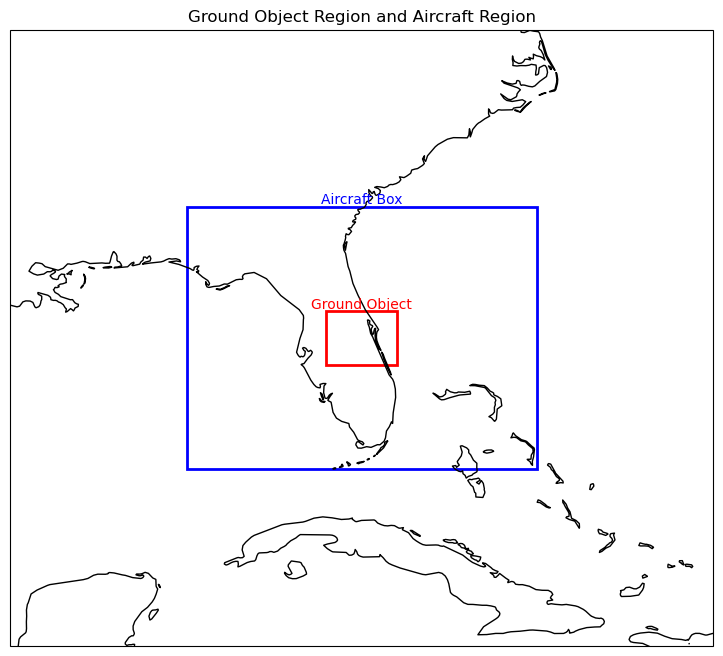

In [2]:
import math
import random
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import pandas as pd

# -----------------------
# Define the Ground Object box (ground object region)
# -----------------------
ground_lon_min, ground_lat_min = -82, 27.5
ground_lon_max, ground_lat_max = -80, 29.0
ground_width = ground_lon_max - ground_lon_min  # 2.0 degrees
ground_height = ground_lat_max - ground_lat_min   # 1.5 degrees

# Compute the center of the ground box
center_lon = (ground_lon_min + ground_lon_max) / 2
center_lat = (ground_lat_min + ground_lat_max) / 2

# -----------------------
# Define the Aircraft bounding box (30% smaller than the 50x area box)
# -----------------------
# Scale up dimensions for a 50x area then reduce by 30%
scale_factor = 50**0.5
aircraft_width = ground_width * scale_factor * 0.7
aircraft_height = ground_height * scale_factor * 0.7

# Center the aircraft box on the ground box center.
aircraft_lon_min = center_lon - aircraft_width / 2
aircraft_lon_max = center_lon + aircraft_width / 2
aircraft_lat_min = center_lat - aircraft_height / 2
aircraft_lat_max = center_lat + aircraft_height / 2

# -----------------------
# Visualization: Plotting Both Boxes
# -----------------------
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add geographic features.
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Draw the Ground Object box (red).
ground_rect = mpatches.Rectangle(
    (ground_lon_min, ground_lat_min),
    ground_width,
    ground_height,
    linewidth=2,
    edgecolor='red',
    facecolor='none',
    transform=ccrs.PlateCarree()
)
ax.add_patch(ground_rect)
ax.text((ground_lon_min + ground_lon_max) / 2, ground_lat_max,
        "Ground Object", color='red',
        ha='center', va='bottom', transform=ccrs.PlateCarree())

# Draw the Aircraft bounding box (blue).
aircraft_rect = mpatches.Rectangle(
    (aircraft_lon_min, aircraft_lat_min),
    aircraft_width,
    aircraft_height,
    linewidth=2,
    edgecolor='blue',
    facecolor='none',
    transform=ccrs.PlateCarree()
)
ax.add_patch(aircraft_rect)
ax.text((aircraft_lon_min + aircraft_lon_max) / 2, aircraft_lat_max,
        "Aircraft Box", color='blue',
        ha='center', va='bottom', transform=ccrs.PlateCarree())

# Set the extent to show both boxes with a margin.
margin_lon = 5
margin_lat = 5
ax.set_extent([aircraft_lon_min - margin_lon, aircraft_lon_max + margin_lon,
               aircraft_lat_min - margin_lat, aircraft_lat_max + margin_lat],
              crs=ccrs.PlateCarree())

plt.title("Ground Object Region and Aircraft Region")
plt.show()


In [3]:
import math
import random
import pandas as pd

# Earth's radius in meters
R = 6371000

# Simulation parameters
total_time = 3600  # seconds (1 hour)
dt = 10            # time step in seconds
num_steps = total_time // dt

# Number of simulation runs
num_runs = 10000

# -----------------------
# Helper Functions
# -----------------------
def haversine(lat1, lon1, lat2, lon2):
    """Calculate the great-circle distance between two points (in meters)."""
    lat1_rad, lon1_rad = math.radians(lat1), math.radians(lon1)
    lat2_rad, lon2_rad = math.radians(lat2), math.radians(lon2)
    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad
    a = math.sin(dlat/2)**2 + math.cos(lat1_rad) * math.cos(lat2_rad) * math.sin(dlon/2)**2
    c = 2 * math.asin(math.sqrt(a))
    return R * c

def update_position(lat, lon, speed, heading, dt):
    """
    Update position based on current lat/lon, speed (m/s), heading (degrees),
    and time step dt. Uses a simple spherical approximation.
    """
    distance = speed * dt
    heading_rad = math.radians(heading)
    delta_north = distance * math.cos(heading_rad)
    delta_east = distance * math.sin(heading_rad)
    delta_lat = (delta_north / R) * (180 / math.pi)
    delta_lon = (delta_east / (R * math.cos(math.radians(lat)))) * (180 / math.pi)
    new_lat = lat + delta_lat
    new_lon = lon + delta_lon
    new_lon = (new_lon + 180) % 360 - 180  # normalize longitude
    new_lat = max(min(new_lat, 90), -90)   # constrain latitude
    return new_lat, new_lon

def horizon_distance(alt):
    """
    Calculate the horizon distance (in meters) for a given altitude 'alt'
    using the approximation: distance ≈ √(2 * R * alt)
    """
    return math.sqrt(2 * R * alt)

# -----------------------
# Simulation Function
# -----------------------
def simulate_run():
    # Choose a random ground object location within the ground box.
    ground_lon = random.uniform(ground_lon_min, ground_lon_max)
    ground_lat = random.uniform(ground_lat_min, ground_lat_max)
    ground_alt = 1.5  # observer height in meters

    # Choose a random aircraft initial position within the aircraft bounding box.
    init_plane_lat = random.uniform(aircraft_lat_min, aircraft_lat_max)
    init_plane_lon = random.uniform(aircraft_lon_min, aircraft_lon_max)

    # Randomly select the aircraft altitude between 150 ft and 65,000 ft (converted to meters).
    plane_alt = random.uniform(150 * 0.3048, 65000 * 0.3048)

    # Aircraft speed and heading.
    plane_speed = 250  # m/s (~900 km/h)
    plane_heading = random.uniform(0, 360)  # degrees

    # Set initial aircraft position.
    plane_lat = init_plane_lat
    plane_lon = init_plane_lon

    # Flag for line-of-sight occurrence.
    los_occurred = False

    for step in range(int(num_steps) + 1):
        # Calculate the great-circle distance between ground object and aircraft.
        distance = haversine(ground_lat, ground_lon, plane_lat, plane_lon)
        # Calculate horizon distances.
        d_ground = horizon_distance(ground_alt)
        d_plane = horizon_distance(plane_alt)
        # If LOS exists at this timestep, flag it.
        if distance <= (d_ground + d_plane):
            los_occurred = True
            break
        # Update aircraft position.
        plane_lat, plane_lon = update_position(plane_lat, plane_lon, plane_speed, plane_heading, dt)

    # If LOS occurred at least once, target is 0, otherwise 1.
    target = 0 if los_occurred else 1

    return {
        "ground_lat": ground_lat,
        "ground_lon": ground_lon,
        "ground_alt": ground_alt,
        "init_plane_lat": init_plane_lat,
        "init_plane_lon": init_plane_lon,
        "plane_alt": plane_alt,
        "plane_speed": plane_speed,
        "plane_heading": plane_heading,
        "target": target
    }

# -----------------------
# Run the Simulation and Save Results in a DataFrame
# -----------------------
results = [simulate_run() for _ in range(num_runs)]
df = pd.DataFrame(results)

# Calculate the fraction of runs with target = 1 (i.e. no LOS ever occurred)
fraction_no_los = df["target"].mean()
print(f"Fraction of runs with no LOS (target=1): {fraction_no_los:.4f}")
print("\nDataFrame head:")
print(df.head())


Fraction of runs with no LOS (target=1): 0.3835

DataFrame head:
   ground_lat  ground_lon  ground_alt  init_plane_lat  init_plane_lon  \
0   28.080192  -81.064996         1.5       27.782328      -79.555252   
1   28.185937  -81.119155         1.5       28.900315      -78.659889   
2   28.024290  -81.287847         1.5       28.109820      -83.858528   
3   27.697878  -81.924233         1.5       30.526252      -77.394077   
4   28.734793  -80.133711         1.5       25.283348      -77.618103   

      plane_alt  plane_speed  plane_heading  target  
0   9277.646313          250      77.364570       0  
1  15650.951170          250     261.835017       0  
2   5246.766746          250      68.076413       0  
3   2664.356070          250     324.793352       1  
4  15977.107100          250     202.960550       1  


          feature  importance
5       plane_alt    0.305317
4  init_plane_lon    0.233840
3  init_plane_lat    0.159408
7   plane_heading    0.148472
1      ground_lon    0.077506
0      ground_lat    0.075457
2      ground_alt    0.000000
6     plane_speed    0.000000


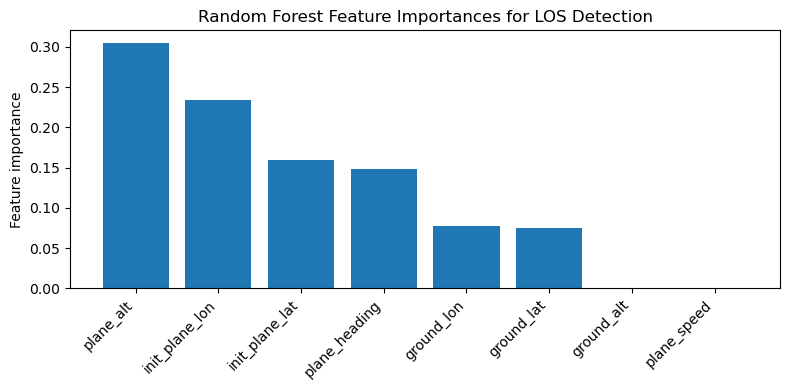

In [20]:
importances = rf.feature_importances_
feat_importance_df = pd.DataFrame({"feature": X_train.columns,
                                   "importance": importances
                                   }).sort_values("importance", ascending = False)

print(feat_importance_df)

plt.figure(figsize = (8,4))
plt.bar(feat_importance_df["feature"], feat_importance_df["importance"])
plt.xticks(rotation = 45, ha = "right")
plt.ylabel("Feature importance")
plt.title("Random Forest Feature Importances for LOS Detection")
plt.tight_layout()
plt.show()

**Comparison of Findings Across the Random Forest, OLS/ANOVA, and Logistic Regression Models**

The Random Forest feature importance results and the statistical analyses from OLS, ANOVA, and logistic regression show a consistent and clear pattern regarding which variables influence LOS detection in the simulation. Across all methods, aircraft altitude (plane_alt) emerges as the strongest predictor. In the Random Forest, it has the highest importance score (approximately 0.314), far ahead of the other features. This matches the statistical models, where plane_alt has extremely small p-values (near zero) in both OLS and logistic regression, and is highly significant in the ANOVA table. This convergence strongly indicates that altitude is the dominant factor influencing whether the aircraft can ever see over the Earth’s curvature.

The next most important variables are init_plane_lon and init_plane_lat, which affect the aircraft’s initial position relative to the ground object. In your Random Forest results, init_plane_lon shows high importance (apprx 0.235) and init_plane_lat shows moderate importance (apprx 0.156). This agrees with the statistical models, init_plane_lon is significant in both ANOVA (p apprx 0.048) and logistic regression (p apprx 0.025), and while init_plane_lat is not statistically significant, its direction and magnitude make sense given its geometric role. These findings show that the aircraft’s starting east-west and north-south separation are relevant to whether LOS will eventually occur.

The Random Forest also gives some weight to plane_heading (importance apprx 0.139), suggesting that flight direction influences how the aircraft moves relative to the ground object during the simulation. However, heading is not statistically significant in the OLS or logistic regression models, indicating that its effect is real but weaker and possibly nonlinwar. Features such as ground_lon (apprx 0.081) and ground_lat (apprx 0.075) have small but nonzero importance scores and mirror the marginal significance of ground_lon in the logistic regression model. Finally, ground_alt and plane_speed show near-zero feature importance and were not significant in any statistical model, confirming they play almost no role in determining LOS outcomes under this simulation setup.

**Key Parameters That Influence LOS Detection**

Taken together, these results show that LOS detection is driven primarily by geometric visibility. The aircraft’s altitude determines how far it can see over the curvature of the Earth, making it the most influential factor by a large margin. The aircraft’s initial position relative to the ground object, especially its initial longitude, determines whether the aircraft begins within a range that can be bridged by the combined horizon distances. Variables that do not significantly affect initial geometry, such as ground altitude (which is nearly constant), aircraft speed, or heading, have far less influence. The agreement between the tree-based model and the regression-based methods strengthens confidence in these conclusions.

**Suggestions for Improving or Extending the Simulation**

Based on the modeling results, several improvements could make the simulation more realistic and deepen the analysis. First, increasing the variation in ground altitude (for example, placing the observer at different elevations or including terrain) could reveal whether ground elevation becomes meaningful when it varies more. Second, experimenting with different aircraft motion patterns, such as approaching the observer directly, circling, or changing altitude during flight, could help determine whether speed or heading become more significant under different behaviors. Third, adding engineered features such as initial great-circle distance or relative bearing may improve interpretability and help simpler models capture the geometry more directly. Finally, running simulations in different geographic regions or expanding the bounding box would help verify whether the importance of initial longitude is location-specific or generalizable.

Overall, the Random Forest, OLS/ANOVA, and logistic regression analyses converge on the same conclusion: aircraft altitude and initial geometric separation are the factors that determine LOS detection, while all other variables play a minor or negligible role in this simulation environment.

In [22]:
#1
t5_model_name = "t5-small"
t5_tokenizer = T5Tokenizer.from_pretrained(t5_model_name)
t5_model = T5ForConditionalGeneration.from_pretrained(t5_model_name)

def summarize_text(text, max_length = 60):
    
    input_text = "summarize: " + text
    inputs = t5_tokenizer(input_text, return_tensors = "pt", truncation = True, padding = "longest")
    summary_ids = t5_model.generate(**inputs, max_length = max_length, num_beams = 4, early_stopping = True)
    return t5_tokenizer.decode(summary_ids[0], skip_special_tokens=True)

article = ("Machine learning models can be used to automatically detect patterns in data. "
           "In this assignment, we simulated line-of-sight conditions between an aircraft "
           "and a ground observer, and then trained several models to predict whether LOS occurs."
          )

print("Original text:\n", article)
print("\nSummary:\n", summarize_text(article))

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


Original text:
 Machine learning models can be used to automatically detect patterns in data. In this assignment, we simulated line-of-sight conditions between an aircraft and a ground observer, and then trained several models to predict whether LOS occurs.

Summary:
 machine learning models can be used to automatically detect patterns in data.


**2. How Inputs & Outputs Are Represented**

T5 uses a Seq2Seq architecture where text is first broken into subword tokens, converted to integer IDs, and mapped to embeddings. The encoder processes the entire input using multi-head self-attention, building a contextual representation for each token. The decoder generates the output summary one token at a time using masked self-attention and cross-attention to the encoder states. Output tokens are converted back into text.

**3. Architecture Explanation**

T5 consists of two stacks of Transformer layers: an encoder and a decoder. Each layer contains multi-head self-attention, a feedforward network, and layer normalization. The decoder includes masked self-attention (to prevent looking ahead) plus cross-attention to the encoder’s outputs. Tokens use learned embeddings with positional encodings. T5 treats all tasks (translation, summarization, QA) as text-to-text by adding task prefixes.

**4. Loss Function**

T5 is trained using cross-entropy loss between the decoder’s predicted distribution and the target output tokens. During training, teacher forcing is used (the correct previous token is fed into the decoder). The model learns to minimize the negative log-likelihood of the correct next token in the target sequence.

**5. Training Challenge & Mitigation**

A major challenge in Seq2Seq models is exposure bias: during training the model sees the true previous token, but during generation it must use its own imperfect outputs, causing errors to cascade. A mitigation strategy is scheduled sampling, gradually replacing true tokens with model-generated tokens during training, making the model more robust during inference.

In [24]:
gpt2_model_name = "gpt2"
gpt2_tokenizer = GPT2Tokenizer.from_pretrained(gpt2_model_name)
gpt2_model = GPT2LMHeadModel.from_pretrained(gpt2_model_name)

def generate_text(prompt, max_new_tokens=60):
    
    inputs = gpt2_tokenizer(prompt, return_tensors = "pt")
    output_ids = gpt2_model.generate(**inputs, max_new_tokens = max_new_tokens, do_sample = True, top_p = 0.9, top_k = 50)
    
    return gpt2_tokenizer.decode(output_ids[0], skip_special_tokens = True)

prompt = ("In this assignment, we explored line-of-sight between aircraft and ground observers. "
          "The results showed that"
         )

print(generate_text(prompt))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


In this assignment, we explored line-of-sight between aircraft and ground observers. The results showed that line-of-sight could be calculated using an alternative approach using an aircraft with a large radius of the field and a more general shape, which allows for a more precise assessment of the position of each observer.

The first approach to line-of-sight is the initial approach to a target


**2. How Inputs & Outputs Are Represented**

GPT-2 tokenizes the prompt into subword units, converts them to IDs, and maps them to embeddings. These embeddings flow through multiple layers of masked multi-head self-attention. GPT-2 generates text autoregressively: each new token is predicted using the entire history of previous tokens. Input and output are both sequences of token embeddings without an encoder/decoder split.

**3. Architecture Explanation**

GPT-2 is a decoder-only Transformer consisting of stacked masked-attention blocks. Each block contains multi-head masked self-attention, a feedforward network, residual connections, and layer normalization. Unlike Seq2Seq models, GPT-2 has no encoder and relies exclusively on causal attention to predict the next token. Positional encodings track token order.

**4. Loss Function**

GPT-2 uses autoregressive language modeling loss, which is simply cross-entropy over the next-token prediction. For each position, the model predicts the next token in the sequence, and the loss penalizes incorrect predictions. Training minimizes the negative log-likelihood of the next token for billions of text tokens.

**5. Training Challenge & Mitigation**

A major challenge is long-range dependency degradation, where the model struggles with information far back in the sequence. Transformers mitigate this with self-attention, but for extremely long contexts, models still fade. Modern techniques such as better positional embeddings (RoPE), sparse attention, and large-scale pretraining + fine-tuning help improve stability and performance.

Seq2Seq models like T5 and decoder-only models like GPT-2 both use the Transformer architecture, but they serve different purposes. T5 uses an encoder–decoder structure that is ideal for tasks where the input and output are distinct sequences, such as translation or summarization. Its main strength is that the encoder fully processes the entire input, allowing the decoder to generate outputs that closely follow the structure and meaning of the original text. However, Seq2Seq models can suffer from exposure bias and require carefully aligned input–output pairs for training. In contrast, GPT-2 is a decoder-only model trained to predict the next token in a sequence. Its strength lies in generating long, fluent text continuations without requiring paired training data. GPT-2 easily produces creative or exploratory text, but it lacks explicit mechsnisms for transforming an input into a different structured output, making it weaker for tasks like translation. If deploying a model in practice, the choice depends on the task: T5 is better for controlled text-to-text transformations, while GPT-2 excels at open-ended generation. The trade-off is structure versus flexibility.

# Sources
[1] Scikit-Learn, Recognizing hand-written digits, https://scikit-learn.org/stable/auto_examples/classification/plot_digits_classification.html
<br>
[2] GeekforGeek, MNIST Dataset : Practical Applications Using Keras and PyTorch, https://www.geeksforgeeks.org/machine-learning/mnist-dataset/ <br>
[3] SciPy, DCT Function Documentation, https://docs.scipy.org/doc/scipy/reference/generated/scipy.fftpack.dct.html <br>
[4] Wikipedia, Discrete cosine transform, https://en.wikipedia.org/wiki/Discrete_cosine_transform <br>
[5] Scikit-Learn, RandomForestClassifier, https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html <br>
[6] GeekforGeek, Random Forest Algorithm in Machine Learning, https://www.geeksforgeeks.org/machine-learning/random-forest-algorithm-in-machine-learning/ <br>
[7] Scikit-Learn, Support Vector Machines, https://scikit-learn.org/stable/modules/svm.html <br>
[8] GeekforGeek, Support Vector Machine (SVM) Algorithm, https://www.geeksforgeeks.org/machine-learning/support-vector-machine-algorithm/ <br>
[9] Medium, Support Vector Machine (SVM), Clearly Explained!, https://python.plainenglish.io/support-vector-machine-svm-clearly-explained-d9db9123b7ac <br>
[10] CVXOPT User's Guide, Quadratic Programming, https://cvxopt.org/userguide/coneprog.html#quadratic-programming <br>
[11] Medium, SVM from scratch using Quadratic Programming, https://medium.com/@ahlawat.randeep/svm-from-scratch-using-quadratic-programming-90b4dbc5e1d2 <br>
[12] Scikit-Learn, Principal component analysis (PCA), https://scikit-learn.org/stable/modules/decomposition.html#pca <br>
[13] GeekforGeek, Principal Component Analysis (PCA), https://www.geeksforgeeks.org/data-analysis/principal-component-analysis-pca/ <br>
[14] Medium, Feature Extraction using principal component analysis (PCA), https://andiyudha.medium.com/feature-extraction-using-principal-component-analysis-pca-4453d020e57f <br>
[15] Medium, Feature Extraction using Principal Component Analysis — A Simplified Visual Demo, https://medium.com/data-science/feature-extraction-using-principal-component-analysis-a-simplified-visual-demo-e5592ced100a <br> 
[16] PyTorch, Training a Classifier, https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html <br>
[17] TensorFlow, Basic classification: Classify images of clothing, https://www.tensorflow.org/tutorials/keras/classification <br>
[18] GeekforGeek, Introduction to Convolution Neural Network, https://www.geeksforgeeks.org/machine-learning/introduction-convolution-neural-network/ <br>
[19] Scikit-Learn, confusion_matrix, https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html <br>
[20] Geek4Geek, Understanding the Confusion Matrix in Machine Learning, https://www.geeksforgeeks.org/machine-learning/confusion-matrix-machine-learning/ <br>
[21] GeekforGeek, Bias-Variance Trade Off - Machine Learning, https://www.geeksforgeeks.org/machine-learning/ml-bias-variance-trade-off/ <br>
[22] GeekforGeekk, Program for distance between two points on earth, https://www.geeksforgeeks.org/dsa/program-distance-two-points-earth/ <br>
[23] statsmodels 0.14.4, statsmodels.stats.anova.anova_lm, https://www.statsmodels.org/stable/generated/statsmodels.stats.anova.anova_lm.html <br>
[24] GeekforGeek, Anova Test, https://www.geeksforgeeks.org/maths/anova-formula/ <br>
[25] GeekforGeek, P-Value: Comprehensive Guide to Understand, Apply, and Interpret, https://www.geeksforgeeks.org/machine-learning/p-value/ <br>
[26] GitHub, The Illustrated Transformer, https://jalammar.github.io/illustrated-transformer/ <br>
[27] GeekforGeek, Transformers in Machine Learning, https://www.geeksforgeeks.org/machine-learning/getting-started-with-transformers/ <br>
[28] towardsdatascience, Classic Seq2Seq model vs. Seq2Seq model with Attention, https://towardsdatascience.com/classic-seq2seq-model-vs-seq2seq-model-with-attention-31527c77b28a/ <br>
[29] GeekforGeek, seq2seq Model, https://www.geeksforgeeks.org/machine-learning/seq2seq-model-in-machine-learning/ <br>
[30] HuggingFace, Model Card for T5 Small, https://huggingface.co/google-t5/t5-small <br>
[31] HuggingFace, GPT-2, https://huggingface.co/openai-community/gpt2 <br>
[32] Kaggle, GPT-2 Text Generation with Prompts and Dataset, https://www.kaggle.com/code/ilhansevval/gpt-2-text-generation-with-prompts-and-dataset <br>
[33] HuggingFace, Transformers, https://huggingface.co/docs/transformers/index <br>
[34] HuggingFace, GPT-2, https://huggingface.co/docs/transformers/model_doc/gpt2